# **CNN for Image Classification**

## Assignment Number : 

- **Student Name**: Sanjay Pahari
- **Roll Number**: 42
- **Group**: Computer Engineering, 7th semester
- **Date**: 26 April 2026
- **Dataset Used**: BatteryDrainSysSim Dataset
- **Personal Note**: https://freaktopus.github.io/LearningDeep
- **Resource Utilized**:   
i. https://learnopencv.com/understanding-convolutional-neural-networks-cnn/

## **Objective**
This assigment focuses on understanding and implementing Convolution Neural Network, vizualization of feature maps. Below are some objectives that this assingments would achieve:

1. Get understanding of following concepts: CNN, feature maps, convoluting and polling.
2. Do experiments on regularization comparing outputs when it is enabled and disabled.
3. Doing demostration on overfiting and anlayzing techniques that reduces overfitting

## **Theoretical Background**

Let's dive little deeper into CNN, feature mapping, convolution and polling.

### Convolution Neural Network

CNN is the basis of computer vision and image processing.

![Fig: Dropout](../../assets/4/conv.png)


There is cross-correlation operation between matrices but not convolution operation. For, convolution operation, the kernal should be 180 degree rotated.

The simple architecture division looks like:

Input Image -> Convolution Layer 1 (Cross-Correlation, Pooling, ReLU) -> Activation Map -> Flattened the Activation Map -> Dense Layer -> Output

![Fig: Dropout](../../assets/4/flowcnn.png)

## Layers:

### Convolution Layers

It can thought as "eyes" of a CNN. Input image (244 x 224 x 3), get computed using filters of same channel size (i.e. 3).

Once cross-correlation opetation is done to get single output (one pixel output), then it is send thorugh an activation funciton, and that output from the activation function is save in the activation map (224 x 224 x 1), since single filter was used so only one map.

Note that since 3 channel was there, so for each channel each filter (3 channel filter with different value than each other) does the operation and summed to get a single matrix, and of elements of those get pass to the activation function to get an activation map.

**Some Terminalolgy:**

**1. Padding:**

It is inclusion of outer pixels or not.

![Fig: Dropout](../../assets/4/padding.png)

**2. Stride:**

It is the step the kernal takes while doing operation.

![Fig: Dropout](../../assets/4/stride.gif)

**Convolution Output Spatial Size Calcualtion**

![Fig: Dropout](../../assets/4/cal.png)

Sobel Kernel is one of the kernel example that is used to detect vertical edges.

[1,0,-1  
2,0,-2  
1,0,-1]

At the last stage of the convolution layer, all the activation maps (channel say) are flattened and then connected to the dense layer.

**3. Max Pooling Layers**

Extract the max value from the kernal size matrix from the activation maps. Pooling can be max(), avg() etc.

![Fig: Dropout](../../assets/4/tillpool.png)

### Fully Connected Classifier Layer

Here, dense layer is present.

![Fig: Dropout](../../assets/4/fc_layer.png)


## **Implementation**

So, let's built CNN model for deepfake image detection.
 
I will be desigining an MLP that can predict the if an image is deepfake or not.

In [3]:
# Initialization

import numpy as np # Numpy is used for tensor operations. Discussed in assignment 1.
import pandas as pd # library for data analysis & manipulation 
# Matplotlib is a library for creating static, animated and interactive visulatizations
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec # help to layout multiple axes

# scikit-learn is a library for simple an efficent tools for predictive data anlaysis and so on built on numpy,scipy and matplotlib
from sklearn.preprocessing import StandardScaler   # only for scaling but not for modelling
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # for calculation
from sklearn.model_selection import train_test_split # for splitting the data into training and testing sets

import random, os

import scipy.stats as stats # it provides algorithms for optimization, integration, interpolation, eigenvalue problems and so on

import seaborn as sns # used for creating statistical graphics

import os
import io
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image, ImageChops, ImageEnhance
from pathlib import Path
from collections import defaultdict

#  PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
# from torchvision.datasets import ImageFolder

#  Metrics
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Reporducibility
SEED = 66
np.random.seed(SEED)
random.seed(SEED)

# Plot Style
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

import kagglehub

/home/sannux/LearningDeep/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Step 1:** 

#### Dataset Load & EDA (Exploratory Data Analysis)

In [4]:
# Download dataset
kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")

'/home/sannux/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2'

Image size (width, height): (256, 256)


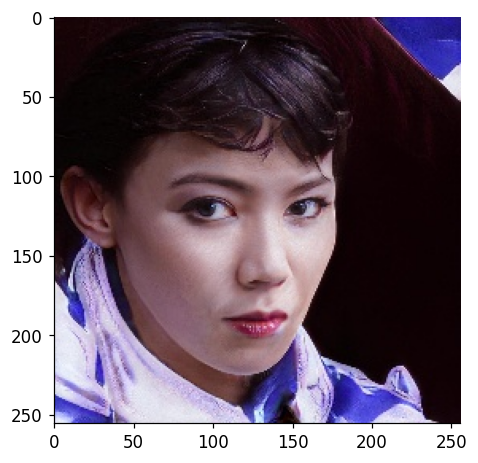

In [5]:
############################
# Dataset Exploration
############################

from PIL import Image

dataset_path = os.path.expanduser("~/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2/real_vs_fake/real-vs-fake/train")

img_dir = os.path.join(dataset_path, "fake")
img_name = random.choice(os.listdir(img_dir))
img_path = os.path.join(img_dir, img_name)

img = Image.open(img_path)
print("Image size (width, height):", img.size)

plt.imshow(img)
plt.axis("on")
plt.show()

In [6]:
############################
# Organizing the dataset
############################

from torch.utils.data import Dataset, DataLoader
import torch


dir_path = os.path.expanduser("~/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2/real_vs_fake/real-vs-fake")
class_names = ["real", "fake"]
label_map = {name: i for i, name in enumerate(class_names)}

# Creating custom dataset class (need __init__, __len__, __getitem__)
class DeepfakeDataset(Dataset):
    def __init__(self, root_dir: str, split: str = "train",
                 transform=None, mode: str = "rgb"):

        self.mode = mode
        self.transform = transform
        self.samples = []
        self.labels = []

        split_path = Path(root_dir) / split

        for class_name in class_names:
            folder = split_path / class_name

            if not folder.exists():
                continue

            for fp in folder.glob("*.jpg"):
                self.samples.append(str(fp))
                self.labels.append(label_map[class_name])

        print(f"[{split}] Loaded {len(self.samples)} images "
              f"(real={self.labels.count(0)}, fake={self.labels.count(1)})")
        
    def __len__(self):
        return len(self.samples)

    def _load_rgb(self, path):
        img = Image.open(path).convert("RGB")
        return self.transform(img) if self.transform else transforms.ToTensor()(img)


    def __getitem__(self, idx):
        path = self.samples[idx]
        label = self.labels[idx]

        tensor = self._load_rgb(path)

        # else:  # BOTH MODE (6 channels)
        #     rgb = self._load_rgb(path)
        #     ela = self._load_ela(path)
        #     tensor = torch.cat([rgb, ela], dim=0)

        return tensor, label
    
#############################################################
#  Transforms
#############################################################
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(), # pixels values from 0.0 to 1.0. And Shape (C,H,W) from (H,W,C)
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std =[0.5, 0.5, 0.5])
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std =[0.5, 0.5, 0.5])
])

train_dataset = DeepfakeDataset(dir_path, "train", mode="rgb")
val_dataset = DeepfakeDataset(dir_path, "valid",  mode="rgb")
test_dataset = DeepfakeDataset(dir_path, "test", mode="rgb")

BATCH_SIZE = 8

train_loader = DataLoader(train_dataset,batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False) # pin_memory= for CPU to GPU, since no GPU so False
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f"\nDataset Info → train:{len(train_loader)} | val:{len(val_loader)} | test:{len(test_loader)}")

[train] Loaded 100000 images (real=50000, fake=50000)
[valid] Loaded 20000 images (real=10000, fake=10000)
[test] Loaded 20000 images (real=10000, fake=10000)

Dataset Info → train:12500 | val:2500 | test:2500


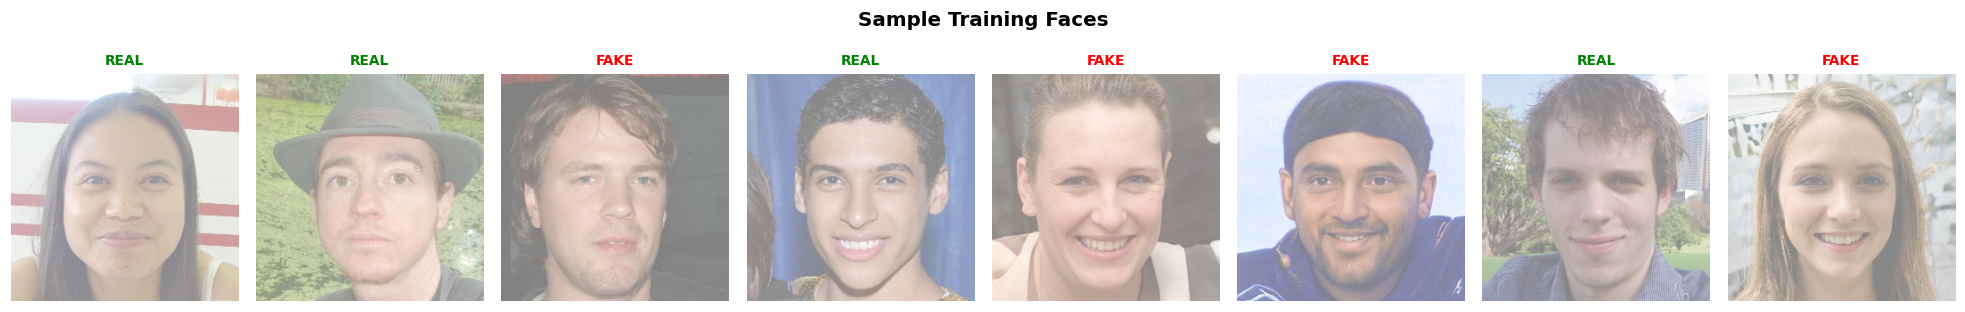

In [7]:
#############################################################
#  Visualize sample training images
#############################################################
def visualize_sample(loader, n=8, title='Sample Training Faces'):

    tensors, labels = next(iter(loader))
    tensors = tensors[:n]
    labels = labels[:n]

    # Denormalize
    imgs = tensors * 0.5 + 0.5
    #
    imgs = imgs.clamp(0, 1).permute(0, 2, 3, 1).numpy()

    fig, axes = plt.subplots(1, n, figsize=(18, 3))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for i, (ax, img, lbl) in enumerate(zip(axes, imgs, labels)):
        ax.imshow(img)
        color = 'green' if lbl.item() == 0 else 'red'
        ax.set_title(class_names[lbl.item()].upper(), color=color, fontsize=9, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

visualize_sample(train_loader, n=8)

### **Step 2:** 

#### CNN Architecture Definitions

In [8]:
###################################################
# Implementing Xception Model for deepfake detection
###################################################
'''
Xception is a deep CNN architecture which can extract more complex features from the images 
which can help detect deepfakes more effectively.
'''

# Implementing Separable Convolution
class SeperableConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=stride, padding=1, groups=in_ch, bias=False) 
        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False)
        
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        return self.relu(x) 
    
class XceptionArch(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        
        #Entry Flow
        self.entry = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        
        # Middle Flow (feature extraction)
        self.block1 = SeperableConv2d(64, 128)
        self.block2 = SeperableConv2d(128, 128)
        
        self.block3 = SeperableConv2d(128, 256)
        self.block4 = SeperableConv2d(256, 256)
        
        self.block5 = SeperableConv2d(256, 512)
        
        # Exit Flow
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512,128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
        )
        
    def forward(self, x):
        x = self.entry(x)
        
        x = self.block1(x)
        x = self.block2(x)
        
        x = self.block3(x)
        x = self.block4(x)
        
        x = self.block5(x)
        
        x = self.global_pool(x)
        
        return self.classifier(x)
    
xcep = XceptionArch(in_channels=3)
out = xcep(torch.randn(1, 3, 128, 128))
total_params = sum(p.numel() for p in xcep.parameters())
print(f"XceptionArch → output shape: {out.shape} | Parameters: {total_params:,}")

XceptionArch → output shape: torch.Size([1, 1]) | Parameters: 349,185


In [9]:
###################################################
# Implementing MesoNet for deepfake detection
###################################################
'''
MesoNet is a shallow CNN architecture designed for deepfake detection.
'''
  
class MesoNet(nn.Module):
    """
    MesoNet-4: 4 convolutional blocks designed to capture
    mesoscopic features (mid-level forgery patterns).
    Input:  (B, 3, 128, 128)
    Output: (B, 1) raw logit for binary classification
    """

    def __init__(self, in_channels: int = 3):
        super().__init__()

        # Block 1 — low-level edge detection
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)                    # 64×64
        )
        # Block 2 — texture anomalies
        self.block2 = nn.Sequential(
            nn.Conv2d(8, 8, kernel_size=5, padding=2),
            nn.BatchNorm2d(8),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)                    # 32×32
        )
        # Block 3 — mid-level forgery patterns
        self.block3 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)                    # 16×16
        )
        # Block 4 — abstract forgery representation
        self.block4 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(4, 4)                    # 4×4
        )
        # Classifier head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)), 
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(16 * 4 * 4, 16),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return self.classifier(x)

    def get_last_conv(self):
        """Return last conv layer for Grad-CAM."""
        return self.block4[0]

mesonet = MesoNet(in_channels=3)
out = mesonet(torch.randn(1, 3, 128, 128))
total_params = sum(p.numel() for p in mesonet.parameters())
print(f"MesoNet → output shape: {out.shape} | Parameters: {total_params:,}")

MesoNet → output shape: torch.Size([1, 1]) | Parameters: 15,689


### **Step 3:** 

#### Training

In [10]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(logits) > 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total   += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in loader:
        imgs   = imgs.to(device)
        labels_t = labels.float().unsqueeze(1).to(device)

        logits = model(imgs)
        loss   = criterion(logits, labels_t)
        probs  = torch.sigmoid(logits)
        preds  = (probs > 0.5).long().squeeze(1)

        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels.to(device)).sum().item()
        total      += imgs.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.squeeze(1).cpu().numpy())

    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

EPOCHS_MAIN = 20
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, name, train_loader, val_loader,
                epochs=EPOCHS_MAIN, lr=LR, weight_decay=1e-4,
                patience=5, checkpoint=None):
    """

    """
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    start_epoch = 1
    best_val_acc  = 0.0
    best_weights  = None

    if checkpoint:
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        best_val_acc = checkpoint.get('best_val_acc', 0.0)
        start_epoch = checkpoint['epoch'] + 1
        print(f"Resuming from epoch {start_epoch}")

    history = defaultdict(list)

    if checkpoint and 'history' in checkpoint:
        for k, v in checkpoint['history'].items():
            history[k].extend(v)
    patience_ctr = 0

    print(f"\n{'='*60}")
    print(f"  Training: {name}")
    print(f"{'='*60}")

    for epoch in range(start_epoch, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        print(f"  Epoch [{epoch:2d}/{epochs}]  "
              f"Train Loss: {tr_loss:.4f} | Train Acc: {tr_acc*100:.2f}%  "
              f"Val Loss: {vl_loss:.4f} | Val Acc: {vl_acc*100:.2f}%")

        # Stop early 
        if True: 
            print("ok true")
            # vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
            torch.save({
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'best_val_acc': best_val_acc,
                'history': history
            }, f"{name}_checkpoint.pth")
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"  ⏹  Early stopping at epoch {epoch} (no val improvement for {patience} epochs)")
                break
    
    if best_weights is not None:
        model.load_state_dict(best_weights)
    print(f"Best Val Acc: {best_val_acc*100:.2f}%")
    return model, dict(history)

## **Experiments**


#### A. MesoNet Architecture Training

In [14]:
#############################################################
#  Experiment 1: Training MesoNet  
#############################################################

checkpoint = torch.load("MesoNet_checkpoint.pth", map_location=DEVICE, weights_only=False)

meso_model = MesoNet().to(DEVICE)
meso_model.load_state_dict(checkpoint['model_state'])
meso_model.eval()

print(checkpoint.keys())

meso_history = checkpoint['history']

# meso_model, meso_history = train_model(
#     MesoNet(in_channels=3), 'MesoNet',
#     train_loader, val_loader, epochs=EPOCHS_MAIN, lr=5e-4, checkpoint = checkpoint
# )

dict_keys(['epoch', 'model_state', 'optimizer_state', 'best_val_acc', 'history'])


#### B. Xception Architecture Training

In [ ]:
#############################################################
#  Experiment 1: Training MesoNet  
#############################################################

# checkpoint = torch.load("Xception_checkpoint.pth", map_location=DEVICE)

xcep_model, xcep_history = train_model(
    XceptionArch(in_channels=3), 'Xception',
    train_loader, val_loader, epochs=EPOCHS_MAIN, lr=5e-4, checkpoint = None
)


  Training: Xception


#### C. Learning Rate Effects

In [ ]:
learning_rates = [1e-4, 5e-4, 1e-3, 5e-3]
lr_results = {}

criterion_tmp = nn.BCEWithLogitsLoss()

for lr_val in learning_rates:
    m = XceptionArch(in_channels=3).to(DEVICE)
    opt = optim.AdamW(m.parameters(), lr=lr_val)
    val_accs = []
    for e in range(5):
        train_one_epoch(m, train_loader, opt, criterion_tmp, DEVICE)
        _, acc, _, _, _ = evaluate(m, val_loader, criterion_tmp, DEVICE)
        val_accs.append(acc)
    lr_results[lr_val] = val_accs
    print(f"  LR={lr_val:.0e} | Best Val Acc: {max(val_accs)*100:.2f}%")

fig, ax = plt.subplots(figsize=(8, 4))
for lr_val, accs in lr_results.items():
    ax.plot(range(1, len(accs) + 1), [a * 100 for a in accs],
            marker='o', label=f'LR={lr_val:.0e}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('XceptionArch: Effect of Learning Rate', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **Dataset Description**

This assigment use deepfake dataset extracted from kaggle.

Link: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces?select=real_vs_fake

``` bash
real-vs-fake/
    train/
        real/
        fake/
    valid/
        real/
        fake/
    test/
        real/
        fake/
```



## **Results**

The results from those model can be plotted into the graphs:

defaultdict(<class 'list'>, {'train_loss': [0.13390417963322485], 'val_loss': [0.1259185147450131], 'train_acc': [0.94759], 'val_acc': [0.95095]})
Training Curves: dict_keys(['MesoNet'])


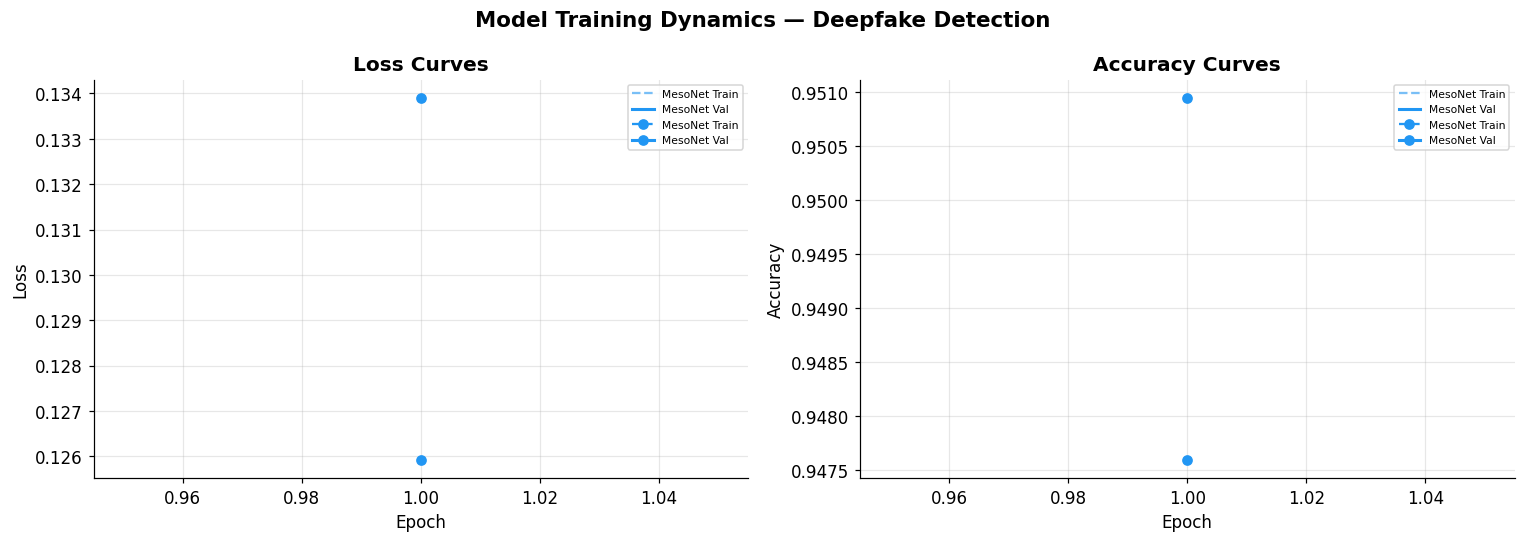

In [18]:
#############################################
# Loss and Accuracy Curves
#############################################

def plot_training_curves(histories: dict):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2196F3', '#4CAF50']

    for ax, metric, title, ylabel in zip(
        axes,
        [('train_loss', 'val_loss'), ('train_acc', 'val_acc')],
        ['Loss Curves', 'Accuracy Curves'],
        ['Loss', 'Accuracy']
    ):
        for (name, hist), color in zip(histories.items(), colors):
            epochs = range(1, len(hist[metric[0]]) + 1)
            ax.plot(epochs, hist[metric[0]], color=color, linestyle='--',
                    alpha=0.6, label=f'{name} Train')
            ax.plot(epochs, hist[metric[1]], color=color, linestyle='-',
                    linewidth=2, label=f'{name} Val')
                    
        ax.plot(epochs, hist[metric[0]],
                color=color, linestyle='--',
                marker='o', markersize=6,
                label=f'{name} Train')

        ax.plot(epochs, hist[metric[1]],
                color=color, linestyle='-',
                marker='o', markersize=6,
                linewidth=2,
                label=f'{name} Val')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight='bold')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

    plt.suptitle('Model Training Dynamics — Deepfake Detection', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


all_histories = {
    'MesoNet'      : meso_history,
    # 'XceptionArch' : xcep_history,
}
print(meso_history)
print("Training Curves:", all_histories.keys())
plot_training_curves(all_histories)

In [20]:
#############################################################
#  Evaluate all models on test set
#############################################################

criterion_test = nn.BCEWithLogitsLoss()
test_results   = {}

for name, model in [('MesoNet', meso_model),
                    # ('XceptionArch', xcep_model)
                    ]:
    
    loss, acc, preds, labels, probs = evaluate(model, test_loader, criterion_test, DEVICE)
    auc = roc_auc_score(labels, probs)
    test_results[name] = {
        'acc': acc, 'auc': auc, 'loss': loss,
        'preds': preds, 'labels': labels, 'probs': probs
    }
    print(f"  {name:20s} Accuracy: {acc*100:.2f}% | AUC: {auc:.4f} | Loss: {loss:.4f}")

  MesoNet              Accuracy: 95.12% | AUC: 0.9908 | Loss: 0.1213


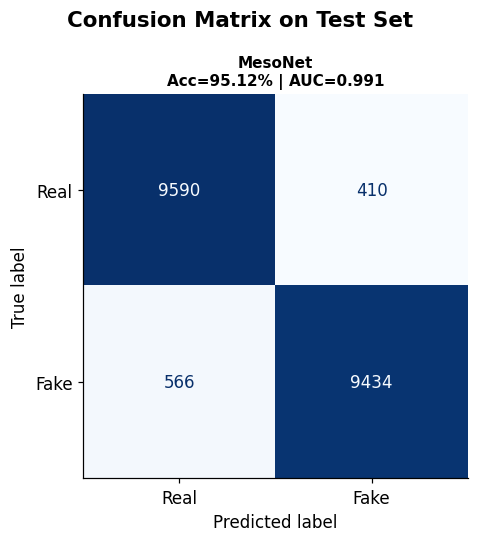

In [27]:
#############################################################
#  Confusion matrices
#############################################################

fig, ax = plt.subplots(figsize=(5, 5))
fig.suptitle('Confusion Matrix on Test Set', fontsize=14, fontweight='bold')

name, res = list(test_results.items())[0]

cm = confusion_matrix(res['labels'], res['preds'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Real', 'Fake'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title(f"{name}\nAcc={res['acc']*100:.2f}% | AUC={res['auc']:.3f}",
             fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [28]:
#############################################################
#  Classification Reports
#############################################################

for name, res in test_results.items():
    print(f"\n{'─'*50}")
    print(f"  Classification Report: {name}")
    print(f"{'─'*50}")
    print(classification_report(
        res['labels'], res['preds'],
        target_names=['Real', 'Fake'], digits=4
    ))


──────────────────────────────────────────────────
  Classification Report: MesoNet
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        Real     0.9443    0.9590    0.9516     10000
        Fake     0.9584    0.9434    0.9508     10000

    accuracy                         0.9512     20000
   macro avg     0.9513    0.9512    0.9512     20000
weighted avg     0.9513    0.9512    0.9512     20000



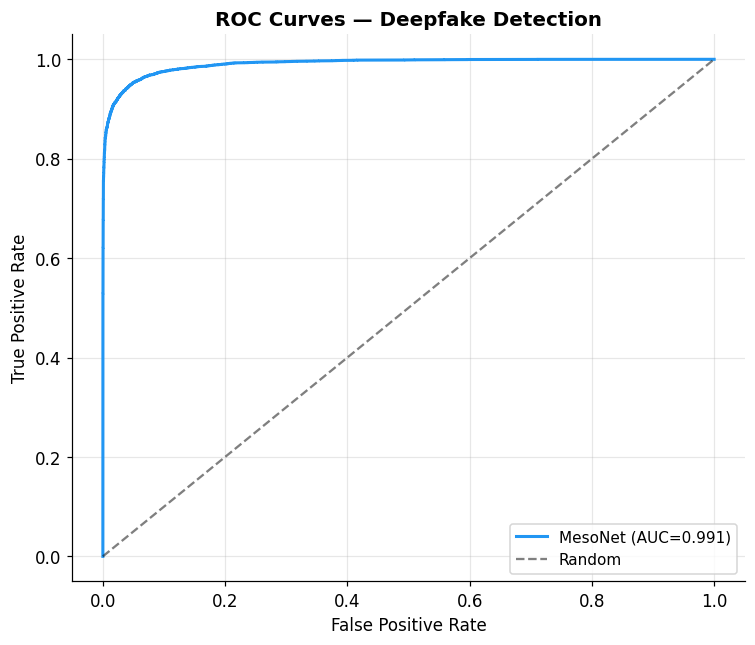

In [29]:
#############################################################
#  ROC Curves for all models
#############################################################

fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#2196F3', '#4CAF50', '#FF5722']

for (name, res), color in zip(test_results.items(), colors):
    fpr, tpr, _ = roc_curve(res['labels'], res['probs'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name} (AUC={res['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Deepfake Detection', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
#############################################################
#  Summary comparison table
#############################################################

summary_data = []
param_counts = {
    'MesoNet'      : sum(p.numel() for p in meso_model.parameters()),
    # 'XceptionArch' : sum(p.numel() for p in xcep_model.parameters()),
}

for name, res in test_results.items():
    summary_data.append({
        'Model'       : name,
        'Parameters'  : f"{param_counts[name]:,}",
        'Test Acc (%)': f"{res['acc']*100:.2f}",
        'ROC-AUC'     : f"{res['auc']:.4f}",
        'Test Loss'   : f"{res['loss']:.4f}",
        'Depth'       : 'Shallow' if name=='MesoNet' else 'Deep'
    })

summary_df = pd.DataFrame(summary_data).set_index('Model')
print(summary_df.to_string())

        Parameters Test Acc (%) ROC-AUC Test Loss    Depth
Model                                                     
MesoNet     15,689        95.12  0.9908    0.1213  Shallow


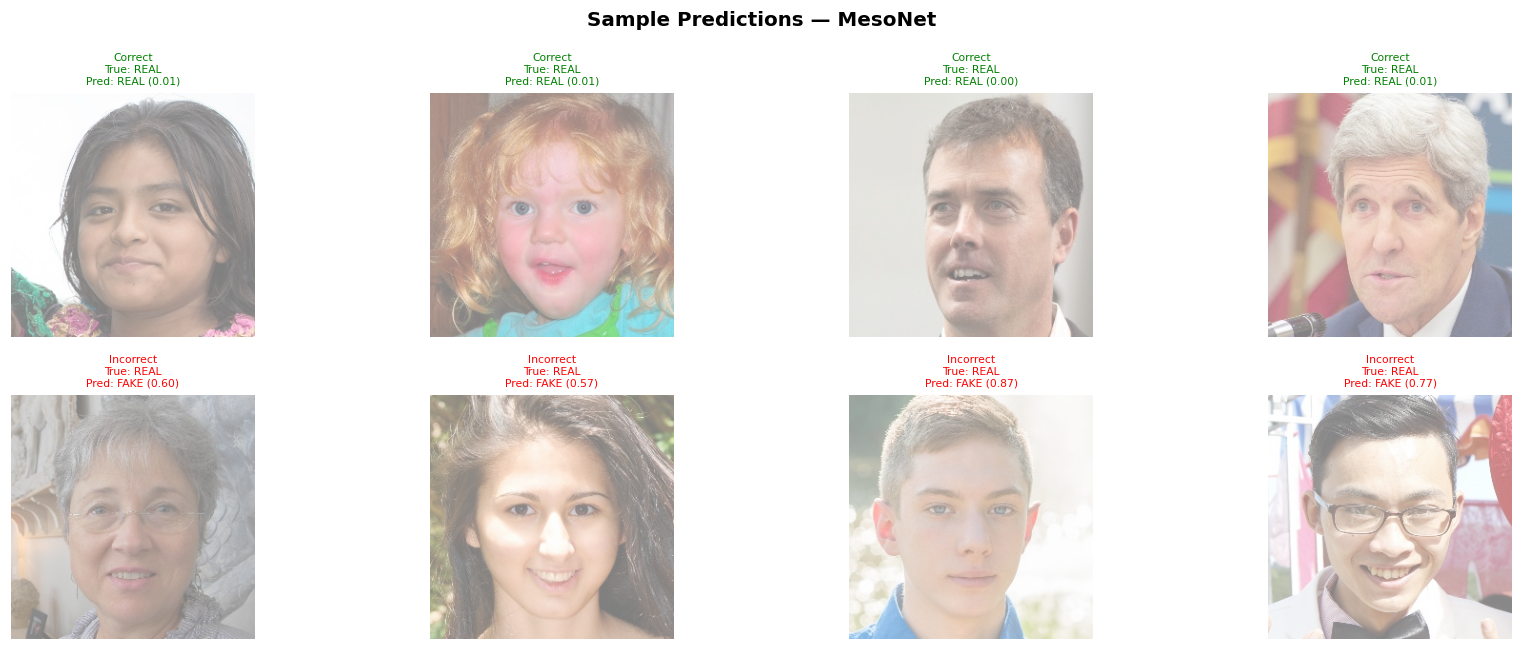

In [31]:
#############################################################
#  Visualize correct & incorrect predictions 
#############################################################

@torch.no_grad()
def show_predictions(model, loader, n_correct=4, n_wrong=4,
                     model_name='MesoNet'):

    model.eval()
    correct_imgs, correct_labels, correct_preds = [], [], []
    wrong_imgs,   wrong_labels,   wrong_preds   = [], [], []

    for imgs, labels in loader:
        logits = model(imgs.to(DEVICE))
        probs  = torch.sigmoid(logits).cpu().squeeze(1)
        preds  = (probs > 0.5).long()

        for i in range(len(imgs)):
            entry = (imgs[i], labels[i].item(), preds[i].item(), probs[i].item())
            if preds[i] == labels[i] and len(correct_imgs) < n_correct:
                correct_imgs.append(entry)
            elif preds[i] != labels[i] and len(wrong_imgs) < n_wrong:
                wrong_imgs.append(entry)

        if len(correct_imgs) >= n_correct and len(wrong_imgs) >= n_wrong:
            break

    all_samples = [(correct_imgs, 'Correct'), (wrong_imgs, 'Incorrect')]

    fig, axes = plt.subplots(2, max(n_correct, n_wrong), figsize=(16, 6))
    fig.suptitle(f'Sample Predictions — {model_name}', fontsize=13, fontweight='bold')

    for row, (samples, row_title) in enumerate(all_samples):
        for col, (img, true_lbl, pred_lbl, prob) in enumerate(samples):
            ax = axes[row, col]
            disp = img.permute(1, 2, 0).numpy() * 0.5 + 0.5
            ax.imshow(np.clip(disp, 0, 1))
            color = 'green' if row == 0 else 'red'
            ax.set_title(
                f"{row_title}\nTrue: {class_names[true_lbl].upper()}\n"
                f"Pred: {class_names[pred_lbl].upper()} ({prob:.2f})",
                fontsize=7, color=color
            )
            ax.axis('off')

        # hide extra axes
        for col in range(len(samples), axes.shape[1]):
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()


show_predictions(meso_model, test_loader)

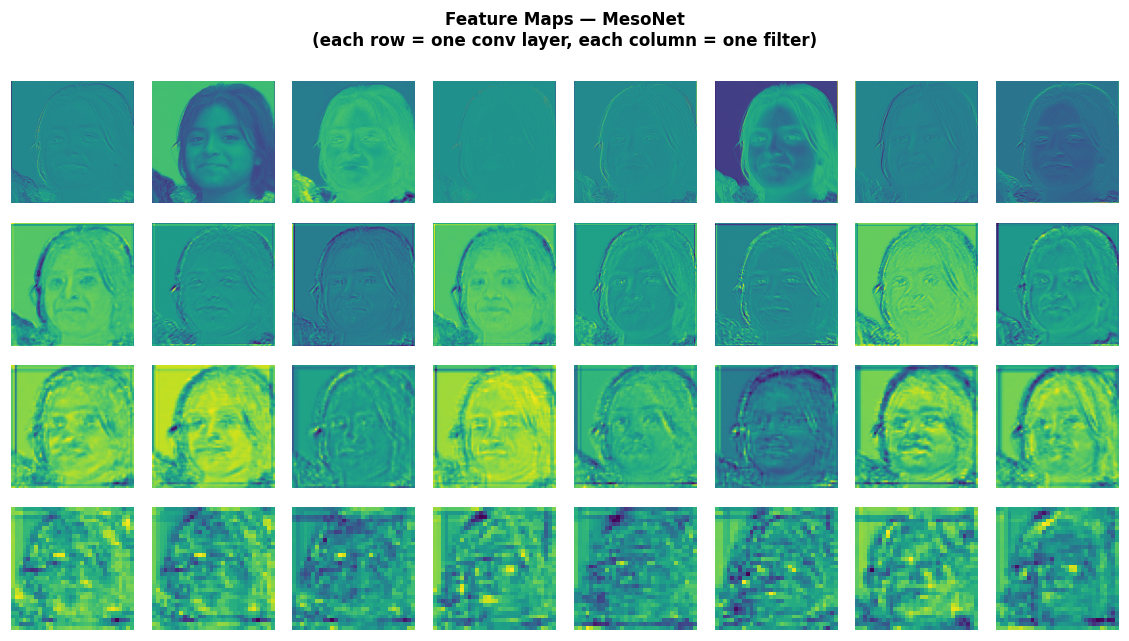

In [32]:
#############################################################
#  Feature Map visualization using forward hooks
#############################################################
def visualize_feature_maps(model, model_name, sample_img_tensor,
                           layer_names, n_maps=16,
                           save_path='feature_maps.png'):
    """
    Register hooks on specified layers and capture activations
    for a single sample image.
    """
    activations = {}
    hooks = []

    def make_hook(name):
        def hook(module, inp, out):
            activations[name] = out.detach().cpu()
        return hook

    # Register hooks on first layer of each block
    if model_name == 'MesoNet':
        targets = [
            ('Block-1 Conv', model.block1[0]),
            ('Block-2 Conv', model.block2[0]),
            ('Block-3 Conv', model.block3[0]),
            ('Block-4 Conv', model.block4[0]),
        ]
    else:
        targets = layer_names

    for name, layer in targets:
        hooks.append(layer.register_forward_hook(make_hook(name)))

    model.eval()
    with torch.no_grad():
        _ = model(sample_img_tensor.unsqueeze(0).to(DEVICE))

    for h in hooks:
        h.remove()

    n_layers = len(activations)
    fig, axes = plt.subplots(n_layers, n_maps,
                             figsize=(n_maps * 1.3, n_layers * 1.5))
    if n_layers == 1:
        axes = axes[np.newaxis, :]

    fig.suptitle(f'Feature Maps — {model_name}\n(each row = one conv layer, each column = one filter)',
                 fontsize=11, fontweight='bold')

    for row, (layer_name, act) in enumerate(activations.items()):
        act = act[0]    # (C, H, W)
        for col in range(min(n_maps, act.shape[0])):
            ax = axes[row, col]
            fm = act[col].numpy()
            ax.imshow(fm, cmap='viridis')
            ax.axis('off')
            if col == 0:
                ax.set_ylabel(layer_name, fontsize=7, rotation=90, labelpad=2)

        for col in range(act.shape[0], n_maps):
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

sample_imgs, sample_labels = next(iter(test_loader))
sample_tensor = sample_imgs[0]

visualize_feature_maps(
    meso_model, 'MesoNet', sample_tensor,
    layer_names=None,     # MesoNet uses named-block approach internally
    n_maps=8,
)

## **Analysis & Discussion**

The insights from the experiments, implementation and study are listed below:

1. Convolution operation is mislead, while cross-correlation operation happens between filter and the input/output matrix.
2. Depends up the convolution layer depth, number of features can be generated.
3. Cross-correlation and pooling makes the dense layer input(flatten input). 

## **Conclusion**

The following points highlight key insights from this assignment:
1. Multiple architecture are out there including Mesonet, Xception and so on.
2. Architectures tweaks in there convolution layer part, making them different to each other. 
3. Dimesional contraints are there that could lead to error in the workflow.